<a href="https://colab.research.google.com/github/AdRavi89/Computer-Vision/blob/main/CV_Praktikum_4_Segmentasi_Thresholding_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Segmentasi Citra (Thresholding & K-Means)

In [1]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


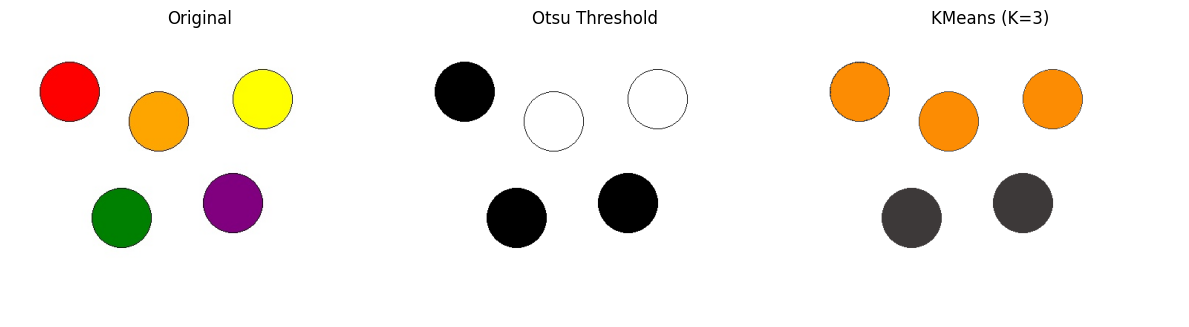

In [2]:
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/dataset/fruits.jpg")
assert img is not None, "fruits.jpg tidak ditemukan."
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Threshold Otsu
otsu,th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# K-Means clustering (BGR)
Z = img.reshape((-1,3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
compactness, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
seg = centers[labels.flatten()].reshape(img.shape).astype(np.uint8)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(th, cmap='gray'); plt.title("Otsu Threshold"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)); plt.title("KMeans (K=3)"); plt.axis("off")
plt.tight_layout(); plt.show()

##Tugas: Segmentasikan objek merah (apel) dari latar belakang menggunakan hasil clustering + masking.

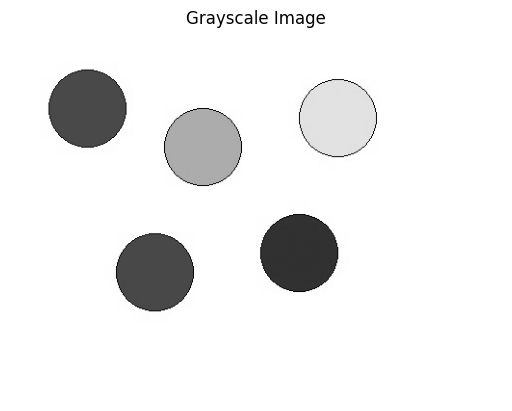

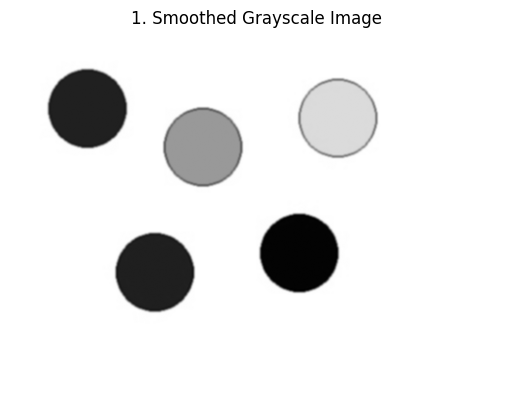

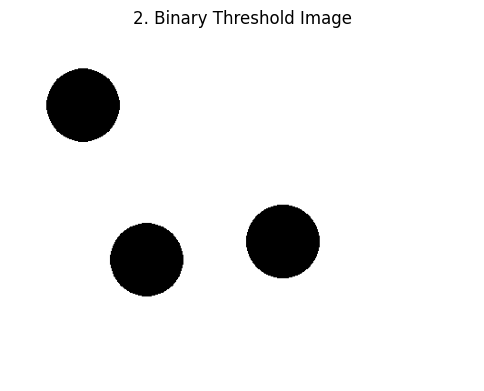

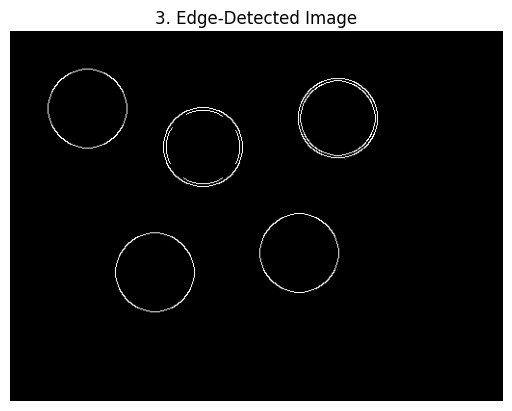

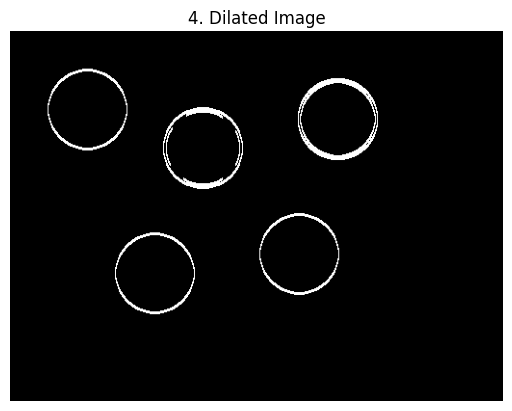

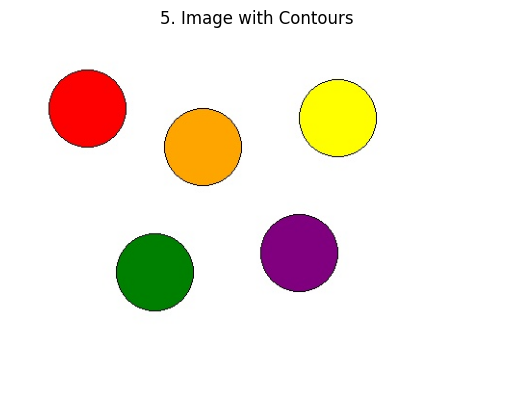

Coins in the image: 5


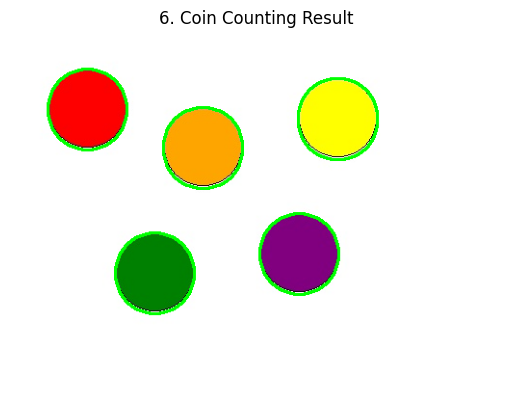

In [8]:
# 1. Preprocessing: (Load image and Convert to grayscale)

image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/dataset/fruits.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()


# 2. Smoothing:
# Apply Gaussian smoothing to the grayscale image to reduce noise
# (Use the cv2.GaussianBlur() function for smoothing)

blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title('1. Smoothed Grayscale Image')
plt.axis('off')
plt.show()


# 3. Thresholding:
# Apply binary thresholding to the smoothed image to create a binary image
# (Use the cv2.threshold() function)

_, thresh = cv2.threshold(
    blur,                  # input image
    127,                   # threshold value
    255,                   # max value
    cv2.THRESH_BINARY
)

# Tampilkan hasil threshold
plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap='gray')
plt.title('2. Binary Threshold Image')
plt.axis('off')
plt.show()


# 4. Edge Detection:
# Apply Canny edge detection to the thresholded image
# (Use the cv2.Canny() function for edge detection)

canny = cv2.Canny(blur, 30, 150)

plt.imshow(canny, cmap='gray')
plt.title('3. Edge-Detected Image')
plt.axis('off')
plt.show()


# Dilasi untuk mempertegas edge
dilated = cv2.dilate(canny, (1,1), iterations=2)

plt.imshow(dilated, cmap='gray')
plt.title('4. Dilated Image')
plt.axis('off')
plt.show()


# 5. Contour Detection:
# Find contours in the edge-detected image
# (using cv2.findContours() function)

contours, _ = cv2.findContours(
    canny.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Create a copy of the original image to draw contours on
contour_image = image.copy()

plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('5. Image with Contours')
plt.axis('off')
plt.show()


# 6. Coin Counting:

(cnt, hierarchy) = cv2.findContours(
    dilated.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cv2.drawContours(rgb, cnt, -1, (0,255,0), 2)

plt.imshow(rgb)
plt.title('6. Coin Counting Result')
plt.axis('off')

print('Coins in the image:', len(cnt))

plt.show()

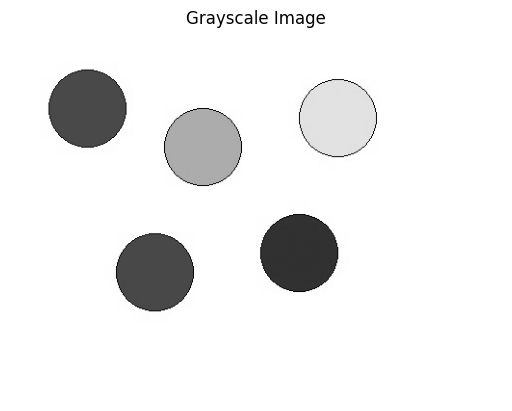

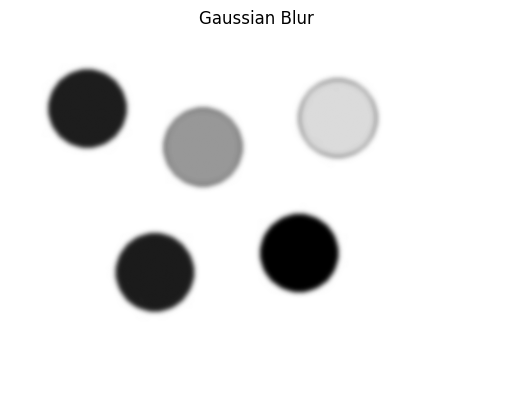

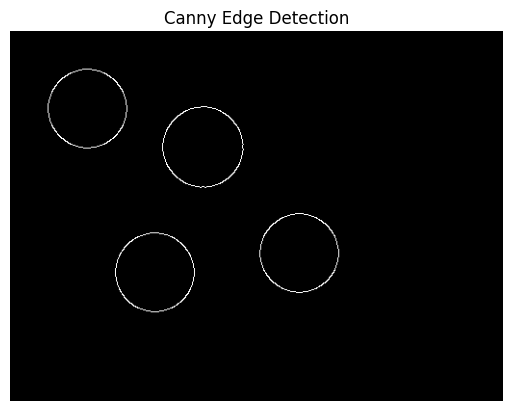

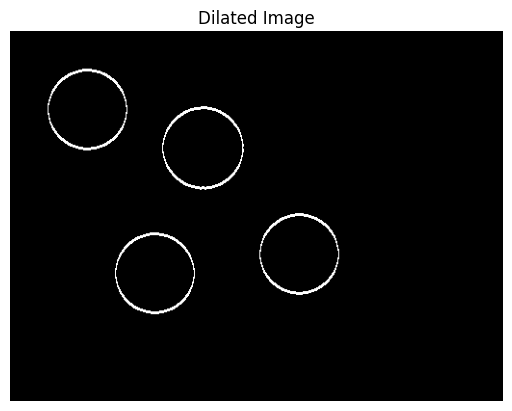

Coins in the image: 4


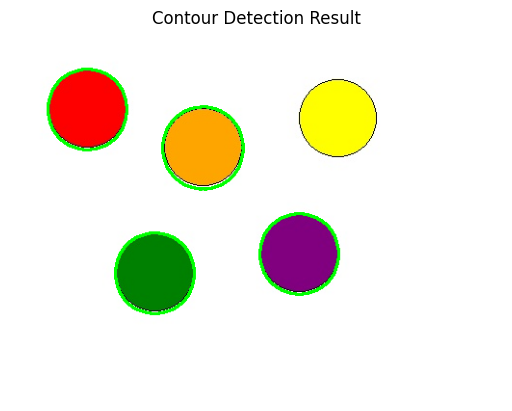

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/dataset/fruits.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

blur = cv2.GaussianBlur(gray, (15,15), 0)

plt.imshow(blur, cmap='gray')
plt.title('Gaussian Blur')
plt.axis('off')
plt.show()

canny = cv2.Canny(blur, 30, 150)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

dilated = cv2.dilate(canny, (1,1), iterations=2)

plt.imshow(dilated, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')
plt.show()

# Find contours in the edge-detected image
contours, _ = cv2.findContours(
    canny.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Create a copy of the original image to draw contours on
contour_image = image.copy()

(cnt, heirarchy) = cv2.findContours(
    dilated.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cv2.drawContours(rgb, cnt, -1, (0,255,0), 2)

plt.imshow(rgb)
plt.title('Contour Detection Result')
plt.axis('off')

print('Coins in the image:', len(cnt))

plt.show()